In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

### Load the Zoom

In [6]:
#base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"
base = "/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom = bacco.Simulation(basedir=base, halo_file="groups_009/fof_subhalo_tab_009", dm_file="snapdir_009/snapshot_009", hy_file="snapdir_009/snapshot_009", sim_format='arepo', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False)

2024-07-08 16:34:22,344 bacco.sims : Initialising simulation Default
2024-07-08 16:34:22,345 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009
2024-07-08 16:34:22,347 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009
2024-07-08 16:34:22,350 bacco.sims : ...done in 0.00533 s


### Load the Original Sim

In [130]:
del mtng

In [131]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

2024-07-08 17:47:21,468 bacco.sims : Initialising simulation Default
2024-07-08 17:47:21,469 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-08 17:47:21,471 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-08 17:47:21,474 bacco.sims : ...done in 0.00591 s
2024-07-08 17:47:21,477 bacco.sims : Reading 98233510 items for GroupPos


2024-07-08 17:47:27,097 bacco.sims : Reading 90246895 items for SubhaloPos


### Let's work in a specific region

We will focus on one of the zoom halos

In [85]:
center = zoom.fof['halo_pos'][0]

In [132]:
L_p = 8
z_slab = 4
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) )[0]

In [133]:
zoom_sel = np.where( (zoom.hy['dm']['pos'][:,0]>(center[0]-L_p/2)) & (zoom.hy['dm']['pos'][:,0]<(center[0]+L_p/2)) &\
                     (zoom.hy['dm']['pos'][:,1]>(center[1]-L_p/2)) & (zoom.hy['dm']['pos'][:,1]<(center[1]+L_p/2)) &\
                     (zoom.hy['dm']['pos'][:,2]>(center[2]-z_slab/2)) & (zoom.hy['dm']['pos'][:,2]<(center[2]+z_slab/2)) )[0]

zoom_grid = bacco.statistics.compute_mesh(pos=zoom.hy['dm']['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-07-08 17:47:35,437 bacco.sims : Reading 98233510 items for Group_M_Crit200


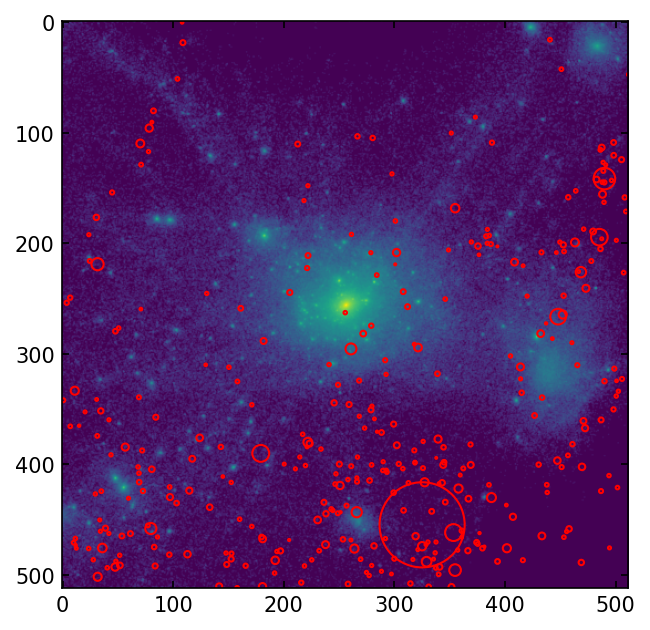

In [134]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

ax.imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))

for i in range(sel_pos.shape[0]):
    circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax.add_artist(circle)

### Cross-match subhalos in the two

In [74]:
zoom_sub_sel = np.where(zoom.sub['MassType'][:,4]!=0)[0]
mtng_sub_sel = np.where(mtng.sub['MassType'][:,4]!=0)[0]

In [69]:
dist, ind = bacco.utils.crossmatch(zoom.sub['pos'][zoom_sub_sel], mtng.sub['pos'][mtng_sub_sel], max_distance=0.5, boxsize=500.000001)

In [71]:
i_clean = np.where(dist!=np.inf)

In [75]:
m_sub_zoom = 1e10 * zoom.sub['MassType'][zoom_sub_sel,4][i_clean]
m_sub_mtng = 1e10 * mtng.sub['MassType'][mtng_sub_sel,4][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

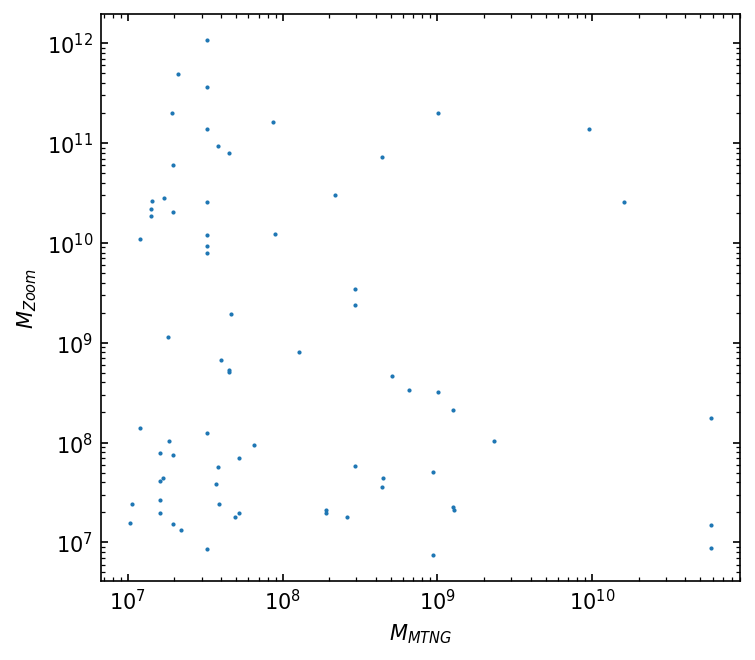

In [76]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_sub_mtng, m_sub_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

### Cross-match FoF groups in the two

In [78]:
zoom_sel = np.where(zoom.fof['halo_m200b']!=0)
mtng_sel = np.where(mtng.fof['halo_m200b']!=0)

In [79]:
dist, ind = bacco.utils.crossmatch(zoom.fof['halo_pos'][zoom_sel], mtng.fof['halo_pos'][mtng_sel], max_distance=0.1, boxsize=500.000001)

In [80]:
# clean the 
i_clean = np.where(dist!=np.inf)

In [81]:
m_zoom = 1e10 * zoom.fof['halo_m200b'][zoom_sel][i_clean]
m_mtng = 1e10 * mtng.fof['halo_m200b'][mtng_sel][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

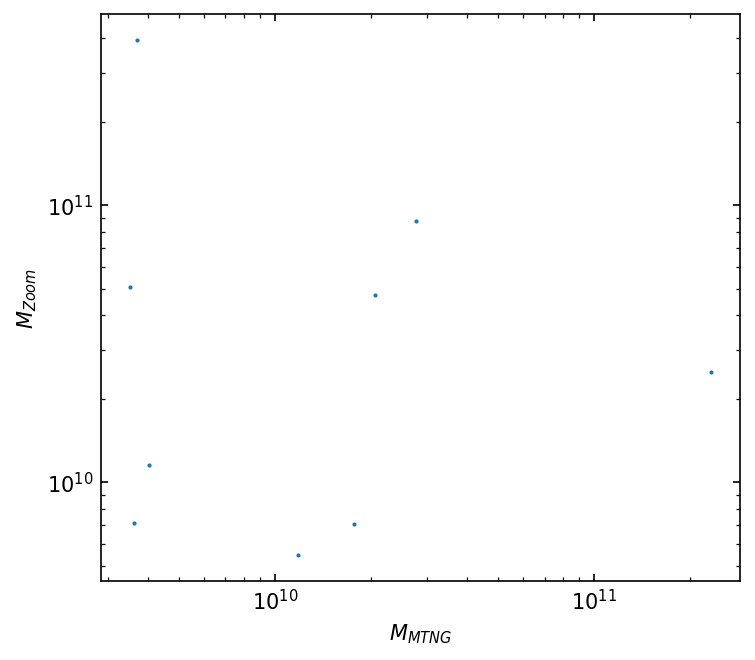

In [82]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_mtng, m_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')